In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
# %matplotlib widget

In [2]:
def load_cycling_data_ch(cell,eSOH_DIR,oCV_DIR,cyc_DIR,cyc_no):
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    cycles = np.array(dfe_0['N'].astype('int'))+1
    # print(cell_no)
    cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
    N1 = cycles[cyc_no]
    # print(N1)
    cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == N1 ]
    cyc_data = cyc_data_raw.reset_index(drop=True)
    t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
    t_c1 = t_c1.values
    I_c1 = cyc_data['Current [mA]']/1000
    I_c1 = I_c1.values
    V_c1 = cyc_data['Voltage [V]']
    V_c1 = V_c1.values
    E_c1 = cyc_data["Expansion [mu m]"]
    E_c1 = E_c1.values
    # idx_I = np.where(np.sign(I_c1[:-1]) != np.sign(I_c1[1:]))[0] 
    # idx_I = idx_I[idx_I>50]
    idx_I = np.where(np.diff(I_c1) < -0.1)[0] 
    t = t_c1[:idx_I[0]]
    V = V_c1[:idx_I[0]]
    I = I_c1[:idx_I[0]]
    E = E_c1[:idx_I[0]]-E_c1[0]
    Q = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
    
    return t,V,I,Q,E


In [3]:
spm = pybamm.lithium_ion.SPM(
    {
        "stress-induced diffusion": "false",
    }
)
param=spm.param
parameter_values = get_parameter_values()

In [4]:
def model_error(data_time,data_current,data_voltage,parameter_values,SOC_0=0,Temp=25,plot_bool=False):
    # t_int = np.arange(0,data_time[-1],1)
    t_int = data_time
    f_I_int = interpolate.interp1d(data_time,-data_current)
    f_V_int = interpolate.interp1d(data_time,data_voltage)
    parameter_values.update(
        {
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
        },
        check_already_exists=False,
    )

    I_int = f_I_int(t_int)
    V_int = f_V_int(t_int)
    timescale = parameter_values.evaluate(spm.timescale)
    current_interpolant = pybamm.Interpolant(
    #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
    t_int, I_int, timescale * pybamm.t
    )

    pybamm.set_logging_level("NOTICE")
    parameter_values["Current function [A]"] = current_interpolant
    # var_pts=var_pts,
    sim = pybamm.Simulation(spm, 
                            parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver(
                                mode="safe", 
                                rtol=1e-6, 
                                atol=1e-6,
                                dt_max=10,
                                )
                            )
    # sim.solve(initial_soc = SOC_0)
    sim.solve(t_eval=t_int,initial_soc = SOC_0)
    solution = sim.solution
    t = solution["Time [s]"].entries
    V_sim = solution["Terminal voltage [V]"].entries
    I_sim = solution["Current [A]"].entries
    # Q = -solution['Discharge capacity [A.h]'].entries
    # f_I_sim = interpolate.interp1d(t,I,bounds_error=False,fill_value="extrapolate")
    # f_V_sim = interpolate.interp1d(t,V,bounds_error=False,fill_value="extrapolate")
    # I_sim = f_I_sim(t_int)
    # V_sim = f_V_sim(t_int)
    I_int = f_I_int(t)
    V_int = f_V_int(t)
    rmse = pybamm.rmse(V_int,V_sim)
    if plot_bool:
        fig, ax1 = plt.subplots(1, 1, figsize=(5, 4), sharex=True)
        ax1.plot(t, V_int, 'k')
        ax1.plot(t, V_sim, 'b--')
        ax1.text(0.7,0.2,f'RMSE: {rmse*1e3:0.1f} mV',transform=ax1.transAxes)
        # ax1.plot(t1, V1, 'r-.')
        ax1.set_ylabel("Voltage [V]")
        # ax1.set_title("Cell 01 Fresh HPPC")
        ax1.set_ylim([3,4.21])
        ax1.set_xlabel("Time [s]")
        # ax1.set_xlim([20370,20470])
        ax1.legend(['data','sim'])
        fig.tight_layout()
        plt.show()
        # fig.savefig(fig_DIR+str(int(10000*random.random()))+".png")
    return rmse

In [5]:
t1_c5,V1_c5,I1_c5,Q1_c5,E1_c5 = load_cycling_data_ch(2,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t1_1p5c,V1_1p5c,I1_1p5c,Q1_1p5c,E1_1p5c = load_cycling_data_ch(5,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t1_2c,V1_2c,I1_2c,Q1_2c,E1_2c = load_cycling_data_ch(8,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t2_c5,V2_c5,I2_c5,Q2_c5,E2_c5 = load_cycling_data_ch(1,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t2_1p5c,V2_1p5c,I2_1p5c,Q2_1p5c,E2_1p5c = load_cycling_data_ch(4,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t2_2c,V2_2c,I2_2c,Q2_2c,E2_2c = load_cycling_data_ch(7,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t3_c5,V3_c5,I3_c5,Q3_c5,E3_c5 = load_cycling_data_ch(3,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t3_1p5c,V3_1p5c,I3_1p5c,Q3_1p5c,E3_1p5c = load_cycling_data_ch(6,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t3_2c,V3_2c,I3_2c,Q3_2c,E3_2c = load_cycling_data_ch(9,eSOH_DIR,oCV_DIR,cyc_DIR,0)

In [6]:
T = 273.15+45
E_r = 39570.0
R = 8.314
np.exp(E_r / R * (1 / 298.15 - 1 / T))

2.7278245079582475

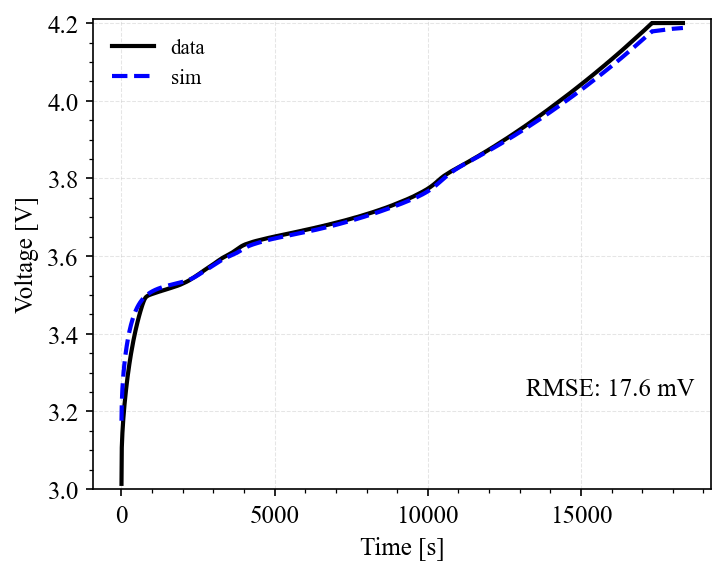

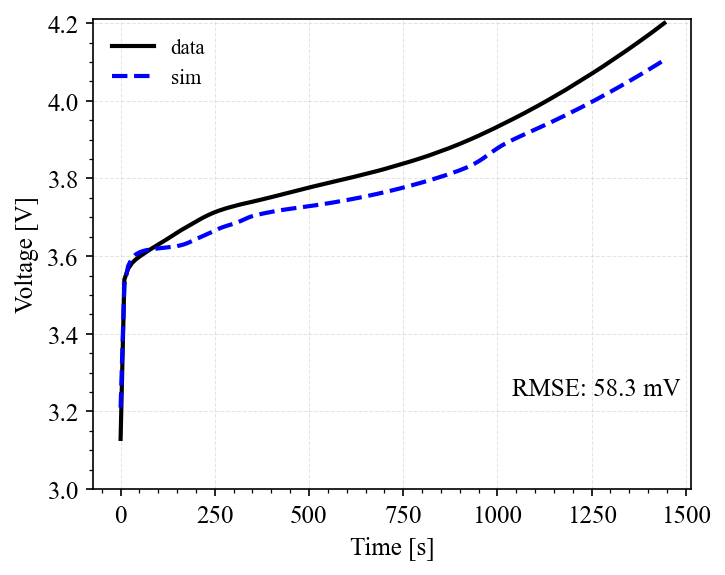

In [7]:
cell = 9
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe_0,spm,parameter_values)
parameter_values = get_parameter_values()
def update_parameters(x):
    parameter_values = get_parameter_values()
    parameter_values.update(
        {
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "SEI resistivity [Ohm.m]": 30000.0,
        },
        check_already_exists=False,
    )
    parameter_values.update(
        {
            "Positive electrode diffusion coefficient activation energy [J.mol-1]": x[4]*10000.0,
            "Negative electrode diffusion coefficient activation energy [J.mol-1]": x[5]*10000.0,
            "Positive electrode reference exchange-current density activation energy [J.mol-1]": x[6]*10000.0,
            "Negative electrode reference exchange-current density activation energy [J.mol-1]": x[7]*10000.0,
            
            "Positive electrode diffusion coefficient [m2.s-1]": x[0]*8e-15,# *0.93,
            "Negative electrode diffusion coefficient [m2.s-1]": x[1]*8e-14,# *30.2,
            "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": x[2]*3.377e-06,#*3.3,
            "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	x[3]*3.183e-06,#*0.62,
            
            # "Positive electrode OCP entropic change [V.K-1]": 0,
            # "Negative electrode OCP entropic change [V.K-1]": 0,
        },
        check_already_exists=False,
    )
    return parameter_values
x = np.array([1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])
parameter_values = update_parameters(x)
plot_bool = True
rmse1 = model_error(t2_c5,I2_c5,V2_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool,Temp=25)
rmse3 = model_error(t2_2c,I2_2c,V2_2c,parameter_values,SOC_0=0,plot_bool=plot_bool,Temp=25)

In [8]:
def prediction_error(x):
    try:
        parameter_values = update_parameters(x)
        # rmse1 = model_error(t1_c5,I1_c5,V1_c5,parameter_values,SOC_0=0.005,plot_bool=False,Temp=-5)
        # rmse2 = model_error(t1_2c,I1_2c,V1_2c,parameter_values,SOC_0=0,plot_bool=False,Temp=-5)
        rmse3 = model_error(t2_c5,I2_c5,V2_c5,parameter_values,SOC_0=0.005,plot_bool=False,Temp=25)
        rmse4 = model_error(t2_2c,I2_2c,V2_2c,parameter_values,SOC_0=0,plot_bool=False,Temp=25)
        rmse5 = model_error(t3_c5,I3_c5,V3_c5,parameter_values,SOC_0=0.005,plot_bool=False,Temp=45)
        rmse6 = model_error(t3_2c,I3_2c,V3_2c,parameter_values,SOC_0=0,plot_bool=False,Temp=45)
        # out = rmse1 + rmse2 + rmse3 + rmse4 + rmse5 + rmse6  
        out = rmse3 + rmse4 + rmse5 + rmse6  
        out = np.array([out])
        # out = rmse1 
        print(f"x={x}, norm={np.linalg.norm(out)}")
    # except pybamm.SolverError:
    except Exception as error:
        out = 5
        out = np.array([out])
        print(f"x={x}, norm={np.linalg.norm(out)}")
        print(error)
        return out
    return out
def train_model():
    timer = pybamm.Timer()
    x0 = np.array([1.2,1.5,0.8,0.6,1.0,2.0,3.0,4.0])
    lower = np.array([1e-1, 1e-1, 1e-1, 1e-1,1e-1, 1e-1, 1e-1, 1e-1])
    upper = np.array([1e+1, 1e+1, 1e+1, 1e+1,1e+1, 1e+1, 1e+1, 1e+1])
    dfo_opts = {
        "init.random_initial_directions":True,
        "init.run_in_parallel": True,
    }
    soln_dfols = dfols.solve(prediction_error, x0,bounds=(lower, upper), rhoend=1e-3, user_params=dfo_opts)
    # soln_dfols = dfols.solve(prediction_error, x0, rhoend=1e-3, user_params=dfo_opts)
    print(timer.time())
    return soln_dfols

In [9]:
soln_dfols = train_model()
xsol = soln_dfols.x

x=[1.2 1.5 0.8 0.6 1.  2.  3.  4. ], norm=0.1383717509491736
x=[1.16527492 1.42157971 0.96948089 0.70355329 0.95313173 1.98349685
 2.96374406 4.33077771], norm=0.15523739164971284
x=[1.27824472 1.32682112 0.92771858 0.73452445 1.17339853 1.94976644
 2.80656447 3.8604643 ], norm=0.15845253917812277
x=[1.19394411 1.59272677 0.69674129 0.73681602 1.29517749 1.94789924
 3.15631492 4.08778093], norm=0.15110671184092497
x=[0.93730576 1.34183279 0.59593747 0.72851322 0.95501322 2.05067635
 2.94422312 3.98928815], norm=0.12795456922140863
x=[1.36638931 1.36264433 0.74545858 0.76247108 0.83957285 1.86212227
 3.19278914 3.95350689], norm=0.15807166123071612
x=[1.01634177 1.45116135 0.89062253 0.46284608 1.03008648 1.69974387
 3.06611471 3.96217534], norm=0.11520979032474082
x=[1.31170181 1.57628835 0.59642539 0.57809729 0.96984331 1.80289752
 2.77746908 4.1024774 ], norm=0.13160307076183575
x=[1.29866078 1.24865858 0.69984768 0.3758174  1.1050298  2.06251603
 3.05161366 4.09592565], norm=0.11351

In [10]:
def plot_fit(x,plot_bool = True):
    parameter_values = update_parameters(x)
    rmse1 = model_error(t1_c5,I1_c5,V1_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool,Temp=-5)
    rmse2 = model_error(t1_2c,I1_2c,V1_2c,parameter_values,SOC_0=0,plot_bool=plot_bool,Temp=-5)
    rmse3 = model_error(t2_c5,I2_c5,V2_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool,Temp=25)
    rmse4 = model_error(t2_2c,I2_2c,V2_2c,parameter_values,SOC_0=0,plot_bool=plot_bool,Temp=25)
    rmse5 = model_error(t3_c5,I3_c5,V3_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool,Temp=45)
    rmse6 = model_error(t3_2c,I3_2c,V3_2c,parameter_values,SOC_0=0,plot_bool=plot_bool,Temp=45)

In [11]:
xsol

array([0.51905385, 1.60663015, 1.17843864, 0.48574332, 0.63860372,
       1.93905378, 2.93480091, 3.58269423])

In [12]:
# Try 1
# xsol = [0.35003913, 1.42627359, 0.82034595, 0.74590533, 2.82725606,
#        1.29056303, 1.5878786 , 1.57708014]
# xsol =  [0.35063669, 1.82864183, 0.73748822, 0.78038094, 2.03887422,
#        1.91907657, 3.59316885, 4.12718516]

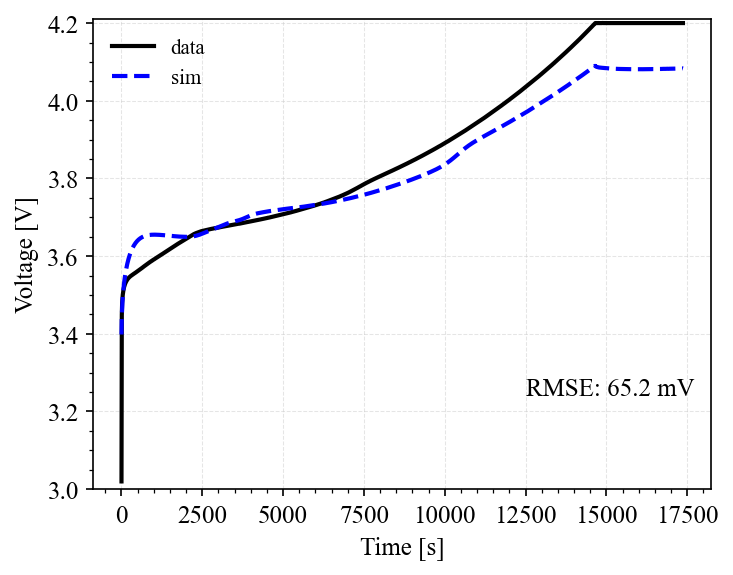

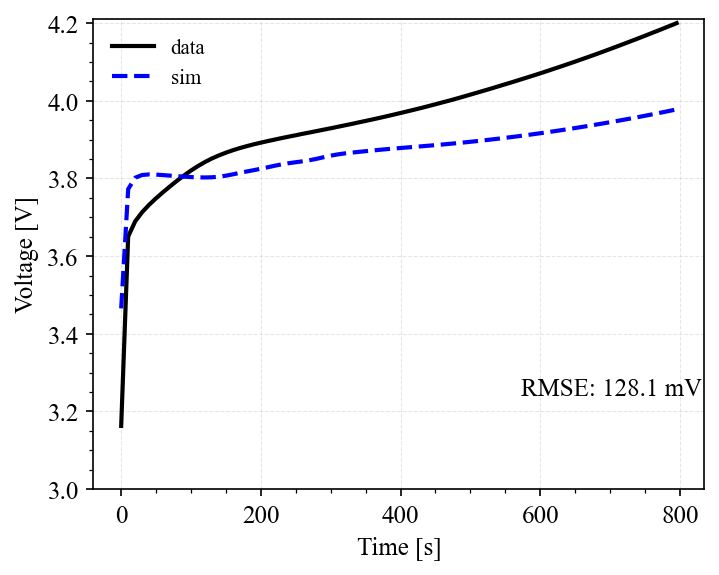

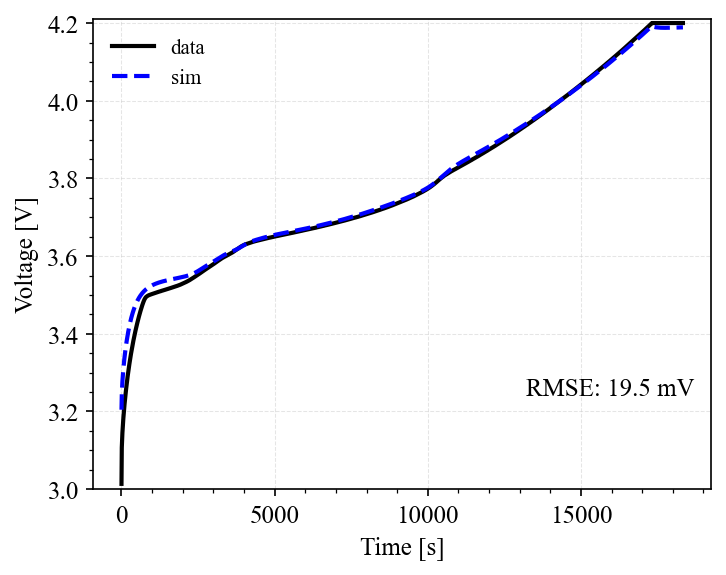

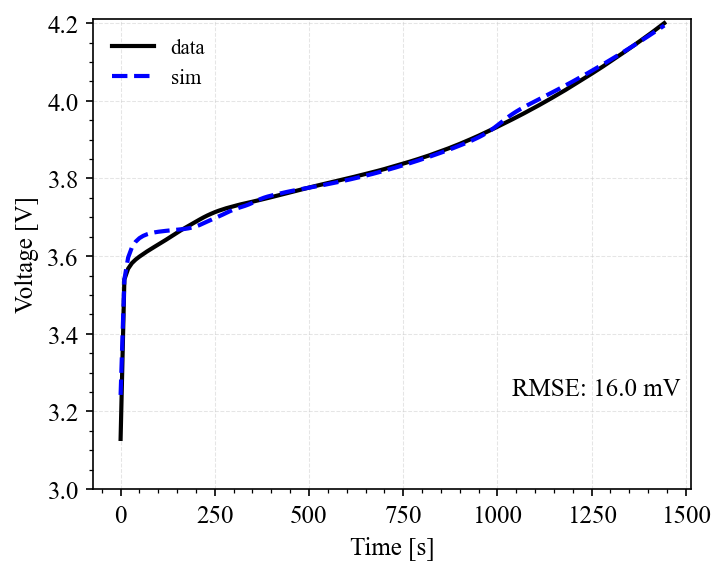

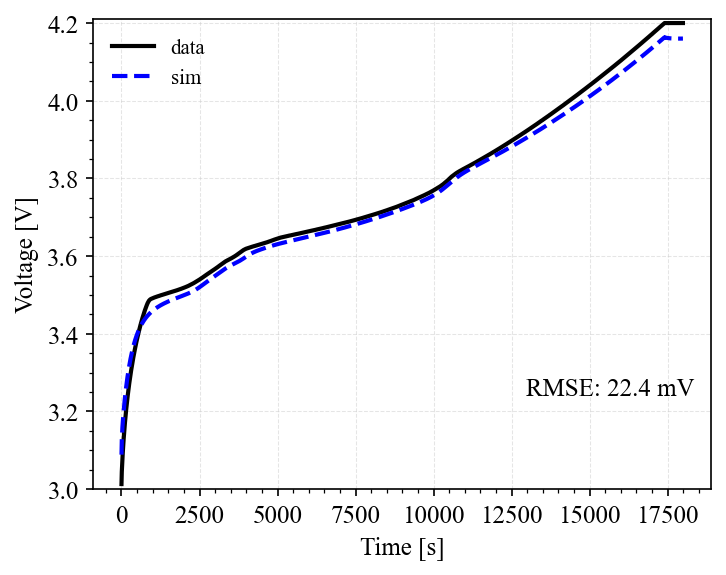

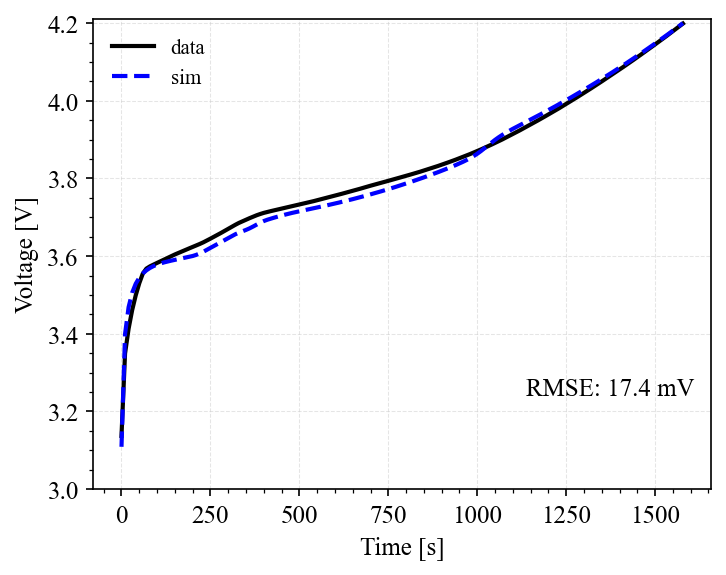

In [13]:
plot_fit(xsol)